Black Friday Retail Sales Analysis
Dataset
retail_black_friday_sales_100k.csv
Scenario
A retail company wants to optimize marketing campaigns during festive sales.
Tasks
1. Perform customer purchase analysis.
2. Identify:
○ Most profitable product categories
○ Gender-based purchasing behavior
○ Age-group spending patterns
3. Analyze:
○ City category vs sales
○ Occupation vs spending
4. Detect high-value customers.
5. Generate business recommendations.
Required Visualizations
Minimum 3:
● Countplot → Gender distribution
● Bar Plot → Product category sales
● Histogram → Purchase distribution
Optional:

● Boxplot
● Heatmap
● KDE Plot
Concepts Covered
● Customer segmentation
● Distribution analysis
● Grouped aggregation
● Business intelligence analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file=pd.read_csv('retail_black_friday_sales_100k.csv')
file.head(15)




,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,T0000001,C007297,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35,99.92,1,99.92,Credit Card,2025-12-01,0,0,0
1,T0000002,C001640,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40,138.03,1,138.03,PayPal,2025-11-24,5,0,0
2,T0000003,C018025,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25,131.00,1,131.00,Credit Card,2025-11-24,14,0,0
3,T0000004,C016050,18-25,Other,Miami,VIP,P3003,Sports,399.61,40,239.77,1,239.77,Credit Card,2025-11-30,23,1,0
4,T0000005,C014629,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30,84.61,2,169.22,Debit Card,2025-11-25,2,0,0
5,T0000006,C009145,46-55,Other,Seattle,Returning,P4013,Accessories,192.91,40,115.75,1,115.75,Gift Card,2025-12-01,17,0,0
6,T0000007,C006718,46-55,Female,San Francisco,Returning,P1445,Home & Kitchen,792.57,25,594.43,1,594.43,Credit Card,2025-11-24,5,0,0
7,T0000008,C005698,46-55,Female,Seattle,Returning,P7501,Footwear,209.35,25,157.01,4,628.04,PayPal,2025-11-27,17,0,0
8,T0000009,C027652,36-45,Female,Los Angeles,Returning,P4350,Groceries,114.32,35,74.31,2,148.62,Cash,2025-12-01,18,0,0
9,T0000010,C002083,36-45,Other,San Francisco,New,P6243,Sports,265.56,30,185.89,1,185.89,Debit Card,2025-11-27,5,0,0


In [ ]:
file.isna()


,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday,sales
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
99996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
99997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
99998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [ ]:
total=file['purchase_amount'].sum()


In [5]:
avg=file['purchase_amount'].mean()
avg

np.float64(351.25630670000004)

Identify:
○ Most profitable product categories

In [15]:
sales=file.groupby('product_category')['purchase_amount'].sum().sort_values(ascending=False)

In [16]:
sales

product_category
Electronics       14123441.47
Home & Kitchen     6461099.92
Sports             3303563.29
Accessories        2754561.54
Footwear           2013317.39
Clothing           1688471.88
Toys               1669209.91
Beauty             1374751.97
Groceries          1075986.12
Books               661227.18
Name: purchase_amount, dtype: float64

In [42]:
avg=file['purchase_amount'].mean()
avg

np.float64(351.25630670000004)

Gender-based purchasing behavior

In [8]:
gender_based=file.groupby('gender')['purchase_amount'].mean()

In [9]:
gender_based

gender
Female    347.846135
Male      352.356149
Other     353.590786
Name: purchase_amount, dtype: float64

Age-group spending patterns

In [10]:
age_based=file.groupby('age_group')['purchase_amount'].mean()

<Axes: xlabel='age_group'>

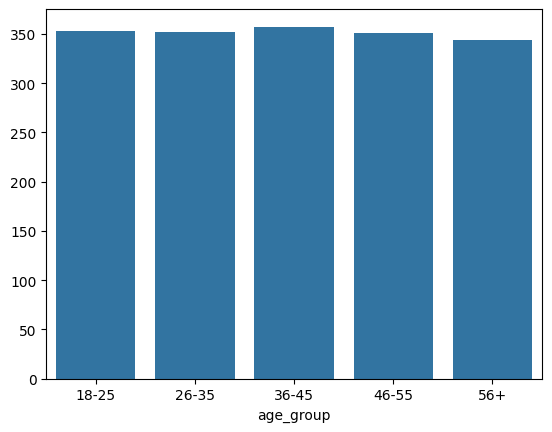

In [44]:
sns.barplot(x=age_based.index,y=age_based.values)

In [11]:
age_based

age_group
18-25    353.012217
26-35    351.800538
36-45    357.253547
46-55    350.468614
56+      343.671791
Name: purchase_amount, dtype: float64

In [27]:
city_sales=file.groupby('city')['purchase_amount'].sum()
city_sales

city
Atlanta          3618348.52
Chicago          3512360.63
Dallas           3547967.43
Houston          3474957.45
Los Angeles      3430433.02
Miami            3566829.80
New York         3546500.70
Phoenix          3526014.43
San Francisco    3445376.30
Seattle          3456842.39
Name: purchase_amount, dtype: float64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Atlanta'),
  Text(1, 0, 'Chicago'),
  Text(2, 0, 'Dallas'),
  Text(3, 0, 'Houston'),
  Text(4, 0, 'Los Angeles'),
  Text(5, 0, 'Miami'),
  Text(6, 0, 'New York'),
  Text(7, 0, 'Phoenix'),
  Text(8, 0, 'San Francisco'),
  Text(9, 0, 'Seattle')])

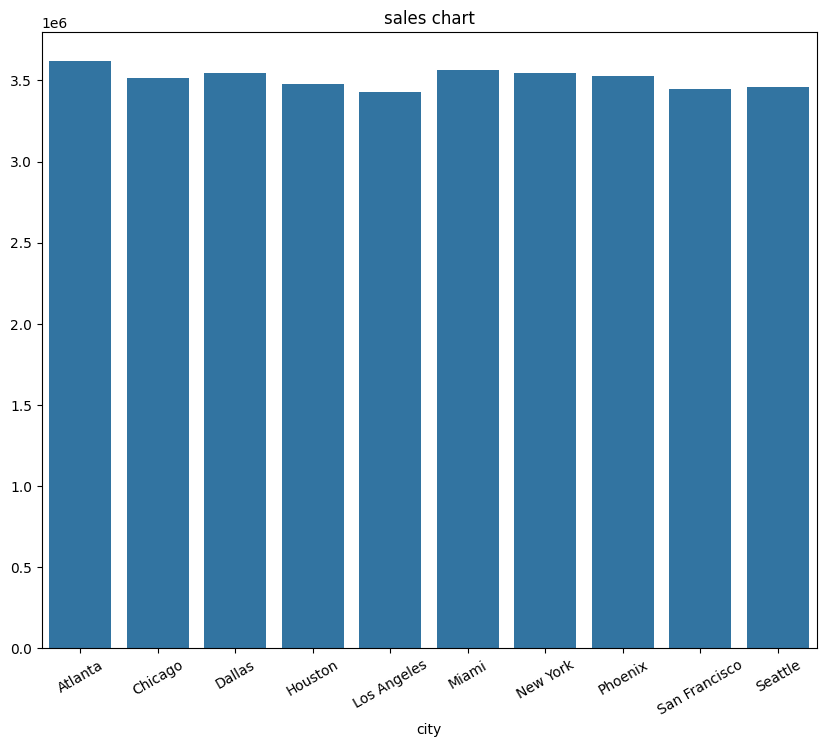

In [28]:
plt.figure(figsize=(10,8))
sns.barplot(x=city_sales.index,y=city_sales.values)
plt.title('sales chart')
plt.xticks(rotation=30)


4. Detect high-value customers.

In [33]:
high_customer=file.groupby('customer_id')['purchase_amount'].sum().sort_values(ascending=False)

In [34]:
high_customer

customer_id
C012695    14057.64
C013072    13654.03
C028692    13207.78
C031820    12449.42
C001139    11871.52
             ...   
C013417        3.92
C023080        3.78
C002246        3.65
C034140        3.56
C027427        2.83
Name: purchase_amount, Length: 32997, dtype: float64

Countplot → Gender distribution

<Axes: xlabel='gender', ylabel='count'>

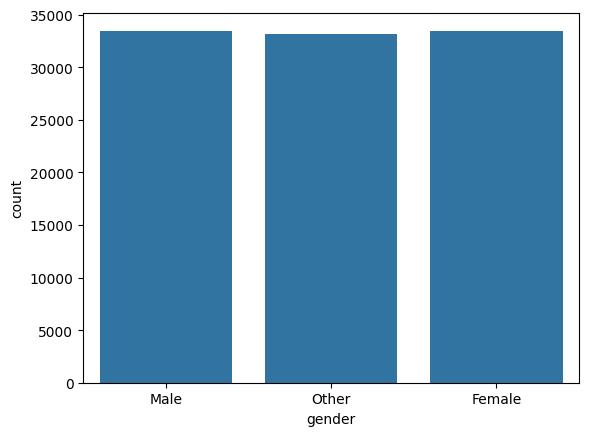

In [35]:
sns.countplot(data=file,x='gender')

Histogram → Purchase distribution

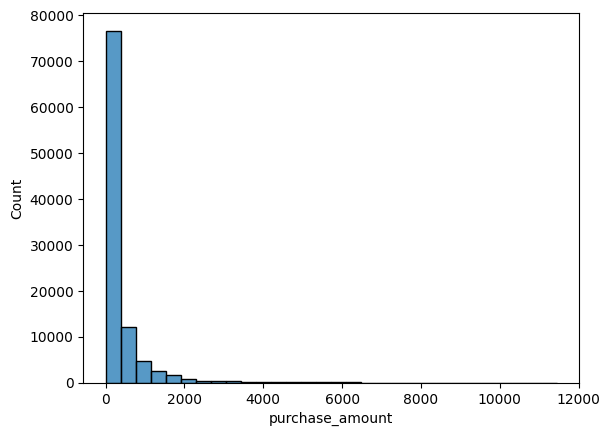

In [37]:
purchase_distribution=sns.histplot(data=file,x='purchase_amount',bins=30)

Bar Plot → Product category sales

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Electronics'),
  Text(1, 0, 'Home & Kitchen'),
  Text(2, 0, 'Sports'),
  Text(3, 0, 'Accessories'),
  Text(4, 0, 'Footwear'),
  Text(5, 0, 'Clothing'),
  Text(6, 0, 'Toys'),
  Text(7, 0, 'Beauty'),
  Text(8, 0, 'Groceries'),
  Text(9, 0, 'Books')])

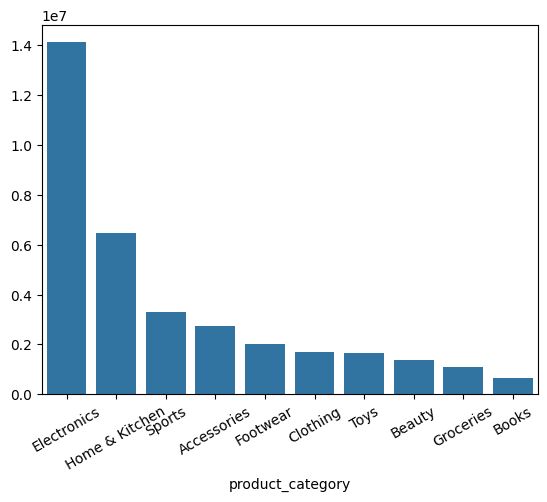

In [46]:
sns.barplot(x=sales.index,y=sales.values)
plt.xticks(rotation=30)

recommendations 

focus on the category that gives the highest revenue like electronics,focus on the gender that purchase the product more 
